In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=pd.read_csv('/content/drive/MyDrive/PLACEMENT AI/preprocessing_dataset.csv')
dat=data
d1,d2,d3=data.copy(),data.copy(),data.copy()

In [ ]:
data.isnull().sum()

,0
Name,0
Age,1
Gender,1
Salary,1
Department,0


In [ ]:
data.head()


,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,NaN,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT


In [ ]:
data.tail()

,Name,Age,Gender,Salary,Department
5,Frank,35.0,NaN,61000.0,Finance
6,Grace,120.0,F,NaN,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


In [ ]:
data.describe()

,Age,Salary
count,9.000000,9.000000
mean,39.555556,57777.777778
std,30.631320,4521.553322
min,22.000000,50000.000000
25%,27.000000,55000.000000
50%,29.000000,59000.000000
75%,35.000000,61000.000000
max,120.000000,63000.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        10 non-null     object 
 1   Age         9 non-null      float64
 2   Gender      9 non-null      object 
 3   Salary      9 non-null      float64
 4   Department  10 non-null     object 
dtypes: float64(2), object(3)
memory usage: 532.0+ bytes


<Axes: >

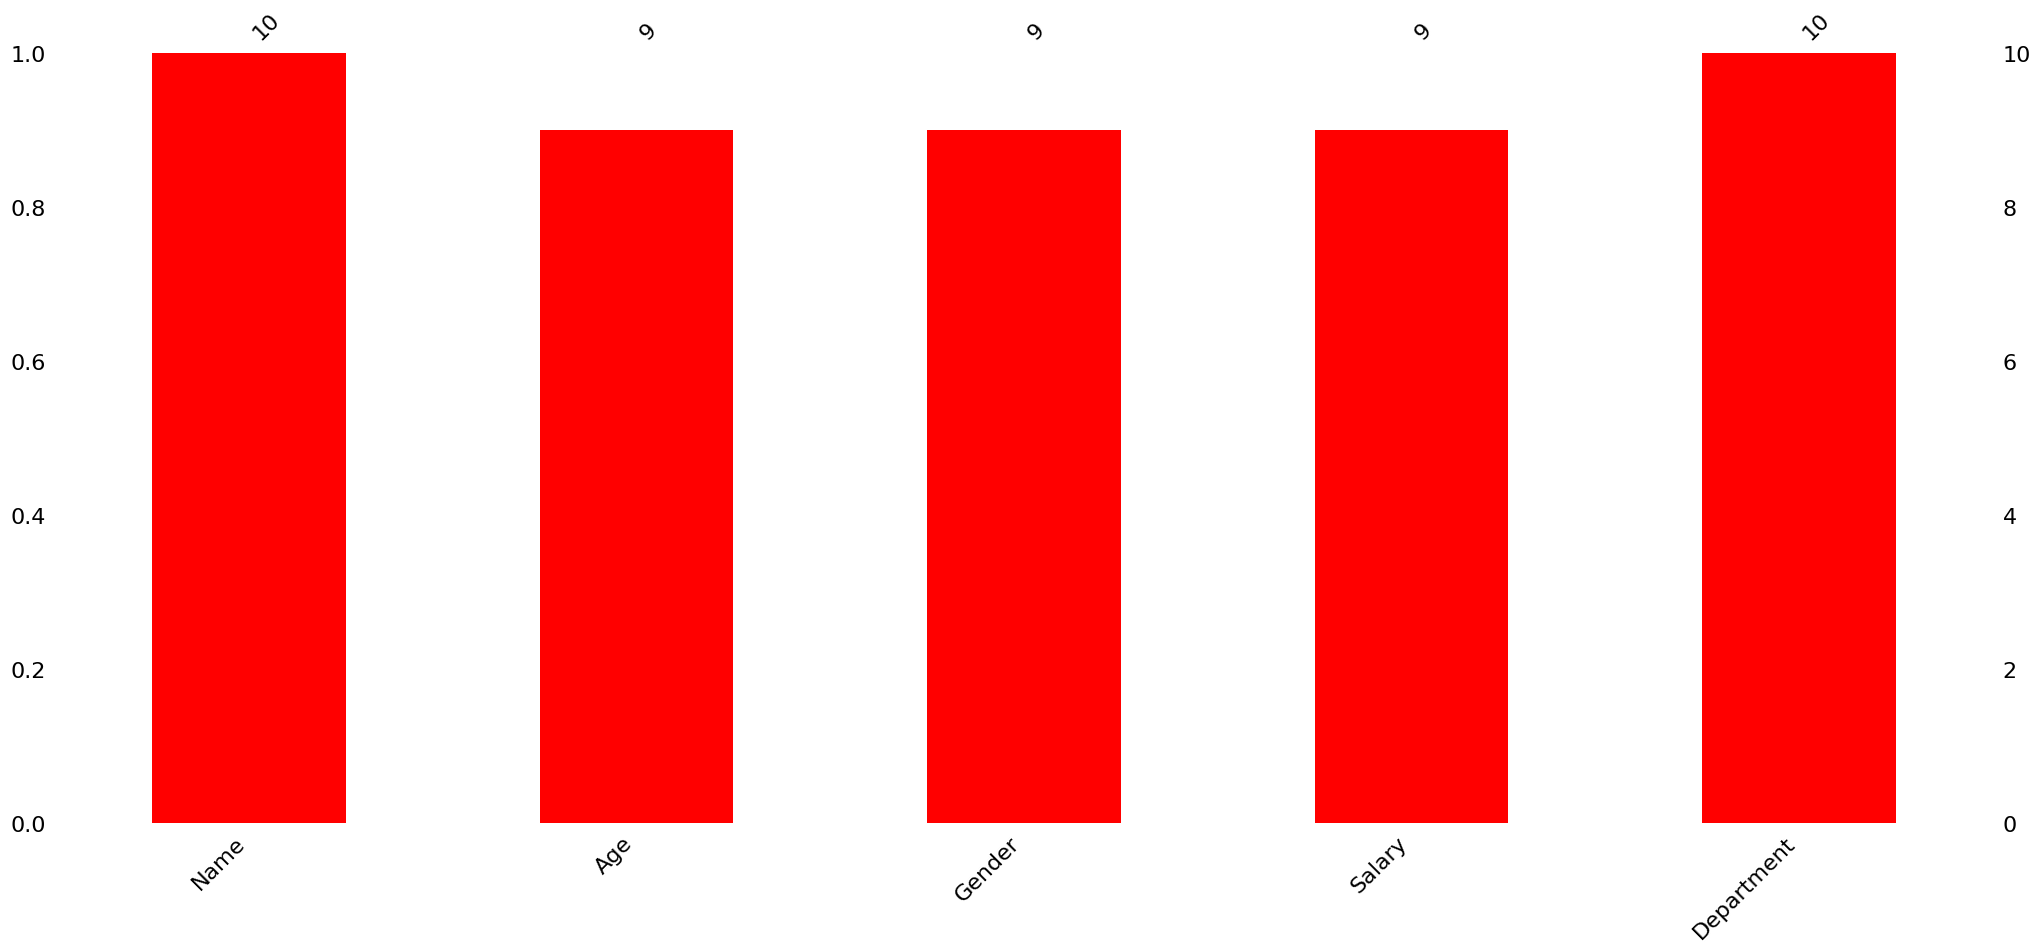

In [ ]:
! pip install missingno
import missingno as msno
msno.bar(data,color='red')

<Axes: >

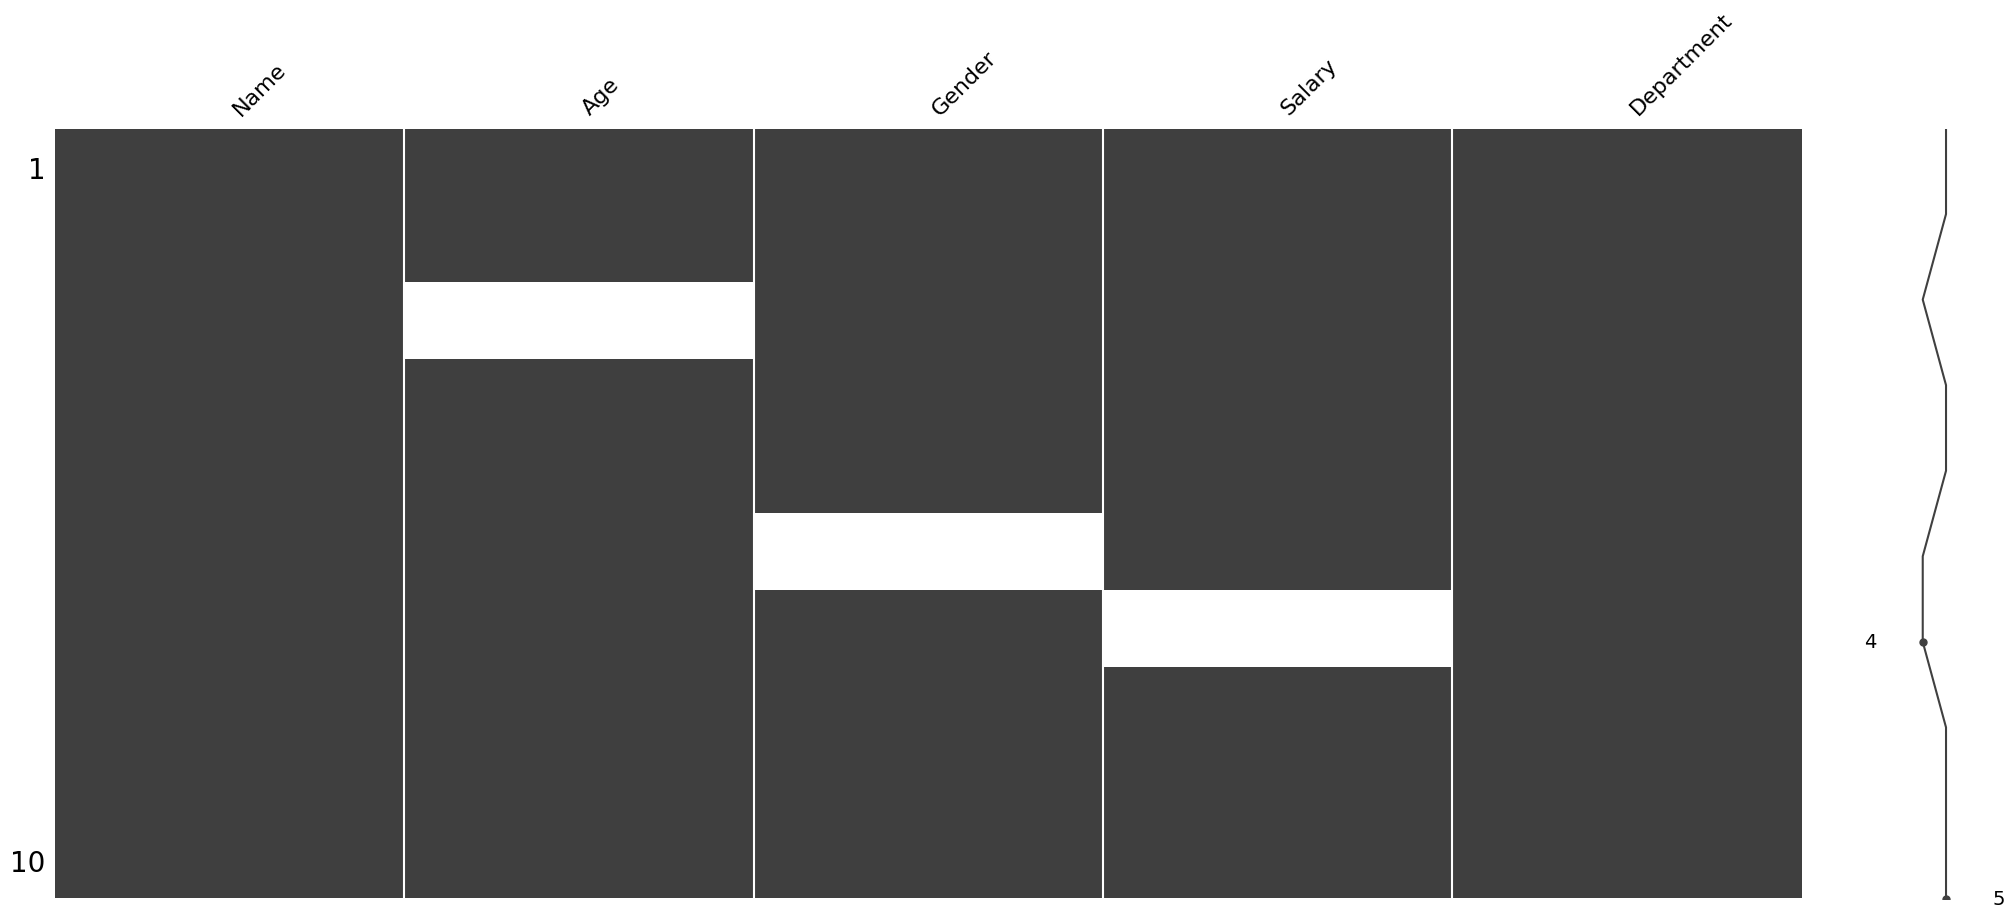

In [ ]:
msno.matrix(data)

<Axes: >

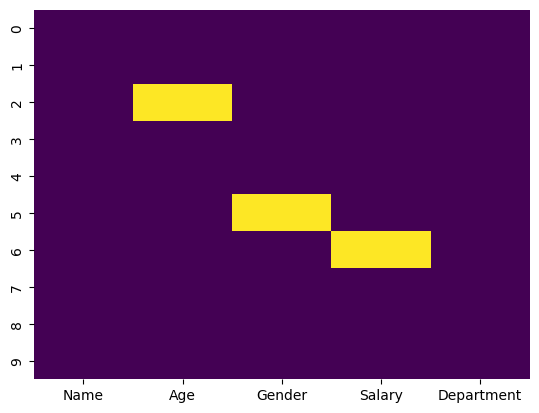

In [ ]:
sns.heatmap(data.isnull(),cbar=False,cmap='viridis')

In [ ]:
data['Age'].fillna(data['Age'].mean(),inplace=True)
data['Salary'].fillna(data['Salary'].mean(),inplace=True)
data['Gender']=data['Gender'].fillna(data['Gender'].mode()[0])

/tmp/ipykernel_3385/868022192.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(),inplace=True)
/tmp/ipykernel_3385/868022192.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

In [ ]:
data

,Name,Age,Gender,Salary,Department
0,Alice,25.000000,F,50000.000000,HR
1,Bob,30.000000,M,60000.000000,Finance
2,Charlie,39.555556,M,55000.000000,IT
3,David,40.000000,M,58000.000000,HR
4,Eve,22.000000,F,52000.000000,IT
5,Frank,35.000000,M,61000.000000,Finance
6,Grace,120.000000,F,57777.777778,Finance
7,Henry,28.000000,M,59000.000000,HR
8,Ivy,29.000000,F,63000.000000,IT
9,Jack,27.000000,M,62000.000000,Finance


In [ ]:
from sklearn.impute import SimpleImputer
imp=SimpleImputer(strategy='median')
d1['Age']=imp.fit_transform(d1[['Age']])
d1['Salary']=imp.fit_transform(d1[['Salary']])



In [ ]:
imp1=SimpleImputer(strategy='most_frequent')
d1[['Gender']]=imp1.fit_transform(d1[['Gender']])

In [ ]:
d1

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,29.0,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT
5,Frank,35.0,M,61000.0,Finance
6,Grace,120.0,F,59000.0,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


OUTLIER

{'whiskers': [<matplotlib.lines.Line2D at 0x7c328b469b50>,
 'caps': [<matplotlib.lines.Line2D at 0x7c328b46a0c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7c328b442420>],
 'medians': [<matplotlib.lines.Line2D at 0x7c328b46a630>],
 'fliers': [<matplotlib.lines.Line2D at 0x7c328b46a900>],
 'means': []}

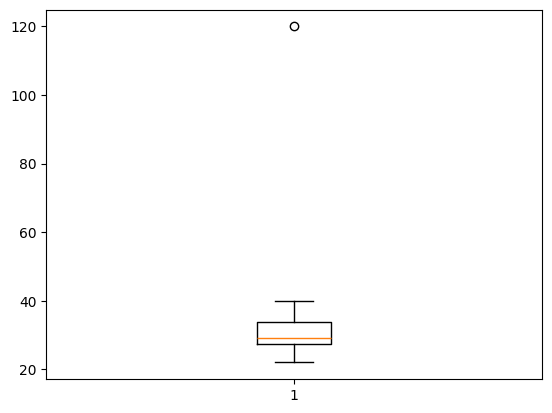

In [ ]:
plt.boxplot(d1['Age'])

<Axes: ylabel='Age'>

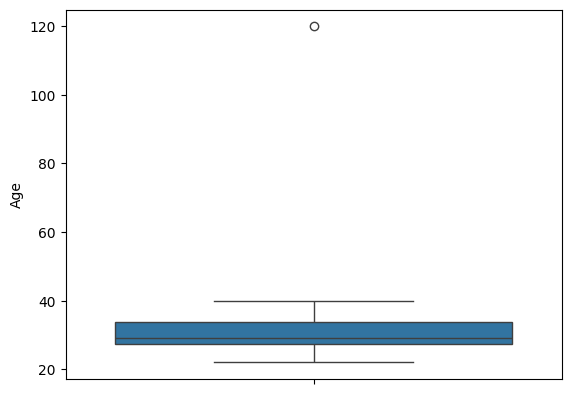

In [ ]:
sns.boxplot(d1['Age'])

In [ ]:
Q1=d1['Age'].quantile(0.25)
Q3=d1['Age'].quantile(0.75)


In [ ]:
IQR=Q3-Q1

up=Q3+1.5*IQR
low=Q1-1.5*IQR
d1[(d1['Age']>up) | (d1['Age']<low)]

,Name,Age,Gender,Salary,Department
6,Grace,120.0,F,59000.0,Finance


In [ ]:
from scipy.stats import zscore
zs=zscore(data['Age'])
outlier=data[np.abs(zs)>2]
print(outlier)

    Name    Age Gender        Salary Department
6  Grace  120.0      F  57777.777778    Finance


In [ ]:
from sklearn.ensemble import IsolationForest
iso=IsolationForest(contamination=.1)
data['Outlier']=iso.fit_predict(data[['Age','Salary']])
data[data['Outlier']==-1]

 #-1 is outliers

,Name,Age,Gender,Salary,Department,Outlier
6,Grace,120.0,F,57777.777778,Finance,-1
